In [1]:
!pip install equinox

zsh:1: command not found: pip


In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    # The printed text block is 4.5 inches wide.
    "full_landscape": (4.50, 2.65),
    "full_standard": (4.50, 3.15),
    "full_tall": (4.50, 4.20),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_GRAYS = {
    "light": "0.72",
    "medium": "0.48",
    "dark": "0.18",
    "black": "0.0",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "Greys",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline
import seaborn as sns
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy import stats
import equinox as eqx
import optax
from typing import Tuple
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
# jax.config.update("jax_enable_x64", True)
key = jr.PRNGKey(10)

# Amortized Inference for Inverse Kinematics

The preceding section developed amortized inference for models with global and local latent variables. This example isolates the amortization mechanism in a single inverse problem: an inference network maps a noisy end-effector observation to an approximate posterior over joint configurations. There is no population layer in this example; it is the base case that the hierarchical construction extends to related systems. The example follows Section 3.4 of {cite:t}`karumuri2024amortized`.

## Forward model and observations

The forward kinematic model maps the joint configuration $\boldsymbol{\xi} = (\xi_1, \xi_2, \xi_3, \xi_4)^T$ (slider height $\xi_1$ and three joint angles $\xi_2, \xi_3, \xi_4$) to the end-effector's 2D position:

$$\mathbf{f}(\boldsymbol{\xi}) = \begin{pmatrix} f_1(\boldsymbol{\xi}) \\ f_2(\boldsymbol{\xi}) \end{pmatrix} = \begin{pmatrix} l_1 \cos(\xi_2) + l_2 \cos(\xi_2 + \xi_3) + l_3 \cos(\xi_2 + \xi_3 + \xi_4) \\ \xi_1 + l_1 \sin(\xi_2) + l_2 \sin(\xi_2 + \xi_3) + l_3 \sin(\xi_2 + \xi_3 + \xi_4) \end{pmatrix}$$

where arm lengths $l_1 = 0.5$, $l_2 = 0.5$, and $l_3 = 1.0$. We observe a noisy version of the end-effector position, contaminated with a Gaussian distribution as:

$$\mathbf{y} \sim \mathcal{N}(\mathbf{f}(\boldsymbol{\xi}), \gamma^2 \mathbf{I}) = \mathcal{N}\left(\mathbf{f}(\boldsymbol{\xi}), 
\begin{pmatrix}
1 \times 10^{-4} & 0 \\
0 & 1 \times 10^{-4}
\end{pmatrix}\right)$$

where $\gamma^2 = 1 \times 10^{-4}$ is the observation noise variance (assumed to be known).

```{figure} ../../images/kinematic_system_view.svg
:name: fig-inverse-kinematics-system
:alt: A vertical slider supports a planar arm with three revolute joints and an end effector.
:width: 55%
:align: center

The slider and three revolute joints define the four-component configuration $\boldsymbol{\xi}$. Adapted, cropped, and restyled from Figure 18(a) of {cite:t}`karumuri2024amortized` under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
```



In [4]:
# System constants
xi_dim = 4 
y_dim = 2
noise_scale = jnp.array([0.01, 0.01])
lens = jnp.array([0.5, 0.5, 1.0]) # lengths of the kinematic links

In [5]:
# Forward kinematics utility functions
# Location of the end points of the links
def segment_points(p_, length, angle):
    """
    Determine location (x2, y2) of link based on (x1, y1), length, and angle.

    Parameters:
        p_ (array): Starting points of the segment, shape (N, 2)
        length (float): Length of the segment
        angle (array or float): Angle(s) in radians

    Returns:
        tuple: (p_, p) where p_ is the original points, 
               and p is the computed end points after applying the length and angle
    """
    p = jnp.zeros(p_.shape)
    p = p.at[:, 0].set(p_[:, 0] + length * jnp.cos(angle))
    p = p.at[:, 1].set(p_[:, 1] + length * jnp.sin(angle))
    return p_, p

# Forward kinematics model
def forward_process(xi):
    """
    Implements the forward process f(xi) and 
    and returns each of the arm’s end points as dictionary.
    """
    values = dict()
    xi = xi.reshape(-1, 4)
    A = jnp.stack([jnp.zeros((xi.shape[0])), xi[:, 0]], axis=1)
    _, B = segment_points(A, lens[0], xi[:, 1])
    _, C = segment_points(B, lens[1], xi[:, 1] + xi[:, 2])
    _, D = segment_points(C, lens[2], xi[:, 1] + xi[:, 2] + xi[:, 3])
    values['A'] = A
    values['B'] = B
    values['C'] = C
    values['D'] = D
    return values

# # Test forward kinematics
# test_xi = jnp.array([[0.1, jnp.pi/12, jnp.pi/6, jnp.pi/6]])
# RESULT = forward_process(test_xi)
# print("Test forward kinematics:", RESULT)
# print("A:", RESULT['A'][0])
# print("B:", RESULT['B'][0])
# print("C:", RESULT['C'][0])
# print("D:", RESULT['D'][0])

## Prior

To set up our inference, we assume a Gaussian prior for our parameters:

$$\boldsymbol{\xi} \sim \mathcal{N}(\mathbf{0}, \text{diag}(\boldsymbol{\sigma}^2)) = \mathcal{N}\left(\mathbf{0}, \begin{pmatrix} \frac{1}{16} & 0 & 0 & 0 \\ 0 & \frac{1}{4} & 0 & 0 \\ 0 & 0 & \frac{1}{4} & 0 \\ 0 & 0 & 0 & \frac{1}{4} \end{pmatrix}\right)$$

In [6]:
# Prior distribution
prior_loc = jnp.zeros(xi_dim)
prior_scale = jnp.array([0.25, 0.5, 0.5, 0.5]) 
prior_xi_dist = {'loc': prior_loc, 'scale': prior_scale}

In [7]:
def sample_prior(prior_xi_dist, key, n, xi_dim):
    """Sample from the prior distribution."""
    # Handle both tuples (from static fields) and arrays
    prior_loc = jnp.array(prior_xi_dist['loc'])[:xi_dim]
    prior_scale = jnp.array(prior_xi_dist['scale'])[:xi_dim]
    return prior_loc[None, :] + prior_scale[None, :] * jr.normal(key, (n, xi_dim))

Let's see how the trajectories reconstructed by this prior look like.

In [8]:
def plot_prior(xi_samples, lens):
    fig = plt.figure(figsize=FIGURE_SIZES["half_standard"])
    axarr = fig.add_subplot(1,1,1)

    # Forward kinematics to get positions of the links
    result = forward_process(jnp.array(xi_samples))
    xi0 = np.array(result['A'])
    xi1 = np.array(result['B'])
    xi2 = np.array(result['C'])
    xi3 = np.array(result['D'])
    plt.axvline(x=0, ls=':', linewidth=0.75, color=BOOK_GRAYS['medium'])
    
    # Plot prior sample trajectories and links
    opts_prior = {'alpha':0.018, 'scale':1, 'angles':'xy', 'scale_units':'xy',
                    'headlength':0, 'headaxislength':0, 'linewidth':1.0, 'rasterized':True}
    prior_legend_line = Line2D([0], [0], color=BOOK_GRAYS['light'], linewidth=1.2, label='Prior samples')
    plt.quiver(xi0[:,0], xi0[:,1], (xi1-xi0)[:,0], (xi1-xi0)[:,1], color=BOOK_GRAYS['light'], **opts_prior)
    plt.quiver(xi1[:,0], xi1[:,1], (xi2-xi1)[:,0], (xi2-xi1)[:,1], color=BOOK_GRAYS['light'], **opts_prior)
    plt.quiver(xi2[:,0], xi2[:,1], (xi3-xi2)[:,0], (xi3-xi2)[:,1], color=BOOK_GRAYS['light'], **opts_prior)
    
    # Plot a sample from prior as the highlighted trajectory
    prior_sample = xi_samples[0:1]  # (1, xi_dim)
    result_sample = forward_process(jnp.array(prior_sample))
    A = np.array(result_sample['A'])
    B = np.array(result_sample['B'])
    C = np.array(result_sample['C'])
    D = np.array(result_sample['D'])

    sample_line = plt.plot(
        [A[0, 0], B[0, 0], C[0, 0]],
        [A[0, 1], B[0, 1], C[0, 1]],
        '-', linewidth=1.4, color=BOOK_GRAYS['black'], marker='o',
        markerfacecolor='white', markeredgecolor=BOOK_GRAYS['black'],
        markersize=3.5, zorder=4, label='One prior sample'
    )[0]

    plt.arrow(
        C[0, 0], C[0, 1],
        D[0, 0] - C[0, 0], D[0, 1] - C[0, 1],
        linewidth=1,
        head_width=0.05,
        head_length=0.04,
        overhang=0.1,
        length_includes_head=True,
        color=BOOK_GRAYS['black'],
        zorder=4
    )

    plt.scatter(
        [A[0, 0]], [A[0, 1]],
        s=100, marker='s', linewidth=1,
        facecolors='white', edgecolors=BOOK_GRAYS['black'], zorder=3
    )

    plt.scatter(
        [A[0, 0], B[0, 0], C[0, 0]],
        [A[0, 1], B[0, 1], C[0, 1]],
        s=10, marker='o', linewidth=1,
        facecolors='white', edgecolors=BOOK_GRAYS['black'], zorder=5
    )
    
    # Plotted range
    rangex = (-0.35, 2.25)
    rangey = (-1.3, 1.3)

    plt.xlim(rangex)
    plt.ylim(rangey)
    plt.xlabel('')
    plt.ylabel('')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(handles=[prior_legend_line, sample_line], loc='best')
    finalize_axes(keep_box=False)
    plt.show()

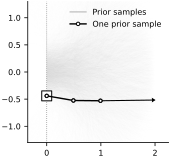

In [9]:
# Plot of reconstructed trajectories by the prior
n_samples = 5000 # number of reconstructed samples
Prior_data = sample_prior(prior_xi_dist, key, n_samples, xi_dim)
plot_prior(Prior_data, lens)

In Amortized Variational Inference (AVI), we use these samples from the prior as our training data. They allow us to learn the map from observed data to the corresponding posterior distribution, which is called the inference function.

### Gaussian guide
For our guide, we use a full-rank multivariate Gaussian, $q_{\phi}(\boldsymbol{\xi}\mid\mathbf{y})=\mathcal{N}(\boldsymbol{\xi}\mid\boldsymbol{\mu}_\phi(\mathbf{y}),\boldsymbol{\Sigma}_\phi(\mathbf{y}))$. To ensure that $\boldsymbol{\Sigma}_\phi$ is positive definite, the network produces a lower-triangular Cholesky factor $\mathbf{L}_\phi$ and sets $\boldsymbol{\Sigma}_\phi=\mathbf{L}_\phi\mathbf{L}_\phi^\top$. See the [variational-inference foundations](../vi/01_basics.md) for details.

In [10]:
def unpack_cholesky(L_diag, L_offdiag, xi_dim):
    """
    Constructs Cholesky L matrix from diagonal and off-diagonal elements.
    
    Args:
        L_diag: Diagonal elements (xi_dim,)
        L_offdiag: Off-diagonal elements (xi_dim*(xi_dim-1)/2,)
        xi_dim: Dimension of the latent space
    
    Returns:
        Lower triangular Cholesky matrix (xi_dim, xi_dim)
    """
    chol_diag = jnp.diag(L_diag)
    chol_offdiag = jnp.zeros((xi_dim, xi_dim))
    tril_indices = jnp.tril_indices(xi_dim, k=-1)
    chol_offdiag = chol_offdiag.at[tril_indices].set(L_offdiag)
    
    q_L = chol_diag + chol_offdiag
    return q_L

### Inference network

We approximate the inference function—the map from an observation $\mathbf{y}$ to the posterior parameters $(\boldsymbol{\mu}_\phi(\mathbf{y}),\mathbf{L}_\phi(\mathbf{y}))$—with a neural network:

In [11]:
class Amortized_VI(eqx.Module):
    """
    Amortized Variational Inference network for Bayesian inverse problems.
    
    Args:
        key: Random key for network initialization
        xi_dim: Dimension of latent variable ξ
        y_dim: Dimension of observation y
        prior_xi_dist: Prior distribution dict with keys "loc" and "scale"
        f: Forward model function
        noise_scale: Observation noise std
    
    Attributes:
        mu: Network outputting posterior mean μ(y)
        L_diag: Network outputting diagonal of Cholesky factor L
        L_offdiag: Network outputting off-diagonal elements of Cholesky factor L
    """
    xi_dim: int = eqx.field(static=True)
    y_dim: int = eqx.field(static=True)
    prior_xi_dist: dict
    f: callable = eqx.field(static=True)
    noise_scale: Tuple[float, ...]
    mu: eqx.nn.Sequential
    L_diag: eqx.nn.Sequential
    L_offdiag: eqx.nn.Sequential

    def __init__(self, key, xi_dim=4, y_dim=2,
                prior_xi_dist=None, f=forward_process, noise_scale=None):
        """
        Initialize the amortized VI network.
        
        Creates three separate neural networks for mu, L_diag, and L_offdiag
        """
        keys = jr.split(key, 9)
        self.xi_dim = xi_dim
        self.y_dim = y_dim
        self.f = f
        self.noise_scale = tuple(np.array(noise_scale))
        self.prior_xi_dist = {
            "loc": np.asarray(prior_xi_dist["loc"], dtype=float),
            "scale": np.asarray(prior_xi_dist["scale"], dtype=float),
        }
        
        self.mu = eqx.nn.Sequential([
            eqx.nn.Linear(self.y_dim, 20, key=keys[0]),
            eqx.nn.Lambda(jax.nn.relu),
            eqx.nn.Linear(20, 10, key=keys[1]),
            eqx.nn.Lambda(jax.nn.relu),
            eqx.nn.Linear(10, self.xi_dim, key=keys[2])
        ])
        
        self.L_diag = eqx.nn.Sequential([
            eqx.nn.Linear(self.y_dim, 20, key=keys[3]),
            eqx.nn.Lambda(jax.nn.relu),
            eqx.nn.Linear(20, 10, key=keys[4]),
            eqx.nn.Lambda(jax.nn.relu),
            eqx.nn.Linear(10, self.xi_dim, key=keys[5]),
            eqx.nn.Lambda(lambda x: jax.nn.softplus(x) + 1e-6)  # Ensure positiveness
        ])
        
        n_offdiag = int(self.xi_dim * (self.xi_dim - 1) / 2)
        self.L_offdiag = eqx.nn.Sequential([
            eqx.nn.Linear(self.y_dim, 20, key=keys[6]),
            eqx.nn.Lambda(jax.nn.relu),
            eqx.nn.Linear(20, 10, key=keys[7]),
            eqx.nn.Lambda(jax.nn.relu),
            eqx.nn.Linear(10, n_offdiag, key=keys[8]),
        ])
        
    def observed_data(self, key, n=30):
        """
        Generate synthetic training data by sampling from prior and adding noise.
        """
        key1, key2 = jr.split(key, 2)
        
        # Sample joint configurations from prior
        xi_data = sample_prior(self.prior_xi_dist, key1, n, self.xi_dim)
        # Generate noisy observations from the prior sample
        y_true = self.f(xi_data)['D']
        noise = jnp.array(self.noise_scale) * jr.normal(key2, y_true.shape)
        y_data = y_true + noise
        
        return xi_data, y_data

    def forward(self, key, num_particles=2, num_training_obs=32):
        """
        Compute ELBO over all the training observations.
        """
        key1, key2 = jr.split(key, 2)
        
        # Generate batch of training data
        _, y = self.observed_data(key1, n=num_training_obs)

        # Infer posterior parameters for all observations in batch
        q_mu = jax.vmap(self.mu)(y)
        q_L_diag = jax.vmap(self.L_diag)(y)
        q_L_offdiag = jax.vmap(self.L_offdiag)(y)

        # Construct full Cholesky matrices L for each observation
        q_L_all = jax.vmap(unpack_cholesky, in_axes=(0, 0, None))(
            q_L_diag, q_L_offdiag, self.xi_dim
        )
        
        def compute_elbo_for_data_point(q_mu_j, q_Lj, y_j, key_j):
            """
            Compute ELBO for a single data point y_j.
            """
            # Sample standard normal variables for reparameterization trick
            particle_keys = jr.split(key_j, num_particles)
            zs = jax.vmap(lambda k: jr.normal(k, (self.xi_dim,)))(particle_keys)
            
            # Reparameterization trick
            xi_samples = q_mu_j[None, :] + zs @ q_Lj.T
            
            # Compute log prior
            prior_loc = self.prior_xi_dist['loc'][:self.xi_dim]
            prior_scale = self.prior_xi_dist['scale'][:self.xi_dim]
            log_prior = jnp.sum(
                stats.norm.logpdf(xi_samples, loc=prior_loc, scale=prior_scale),
                axis=1
            )
            
            # Compute log likelihood
            y_pred = self.f(xi_samples)['D']
            log_likelihood = jnp.sum(
                stats.norm.logpdf(
                    y_j[None, :],
                    loc=y_pred,
                    scale=jnp.array(self.noise_scale)
                ),
                axis=1)
            
            # Average over Monte Carlo samples
            datafit = jnp.mean(log_prior + log_likelihood)
            
            # Entropy term: 0.5 * log(det(2*pi*e*L@L.T))
            diag_Lj = jnp.diag(q_Lj)
            log_det = 2.0 * jnp.sum(jnp.log(jnp.maximum(diag_Lj, 1e-9)))
            entropy = 0.5 * (self.xi_dim * (1.0 + jnp.log(2.0 * jnp.pi)) + log_det)
            
            return datafit + entropy

        # Compute ELBO for each observation in the batch
        n_obs = y.shape[0]
        data_keys = jr.split(key2, n_obs)
        elbos = jax.vmap(compute_elbo_for_data_point)(
            q_mu, q_L_all, y, data_keys
        )
        
        # Return mean ELBO over batch
        return jnp.mean(elbos)

    def __call__(self, key, num_particles=2, num_training_obs=30):
        return self.forward(key,
                            num_particles=num_particles,
                            num_training_obs=num_training_obs)

In [12]:
init_key, train_key = jr.split(key, 2)
model = Amortized_VI(
    key=init_key,
    xi_dim=xi_dim,
    y_dim=y_dim,
    prior_xi_dist=prior_xi_dist,
    f=forward_process,
    noise_scale=noise_scale,
)

To train the amortized VI model, we need to define the loss function and the optimizer settings. We do that as follows:

In [13]:
def train_amortized_vi(model, key, n_steps=10000, num_particles=5):
    """
    Train the amortized variational inference model.
    
    Args:
        model: Amortized_VI instance
        key: Random key
        n_steps: Number of training steps
        num_particles: Number of Monte Carlo samples for ELBO estimation
    
    Returns:
        model: Trained Amortized_VI instance.
        history: Dictionary containing training history with keys:
            - 'steps': List of step numbers
            - 'losses': List of loss values (negative ELBO)
            - 'learning_rates': List of learning rates at each step
    """
    # Learning rate schedule
    learning_rate = optax.piecewise_constant_schedule(
        init_value=0.01, 
        boundaries_and_scales={5000: 0.1}  # Multiply by 0.1 at step 5000
    )
    
    # Initialize Adam optimizer
    optim = optax.adam(learning_rate)

    @eqx.filter_jit
    def compute_loss_and_grads(model, key):
        """
        Compute negative ELBO and gradients.
        """
        loss, grads = eqx.filter_value_and_grad(
            lambda m: -m(key, num_particles=num_particles)
        )(model)
        return loss, grads

    def update_step(model, opt_state, grads):
        """
        Apply one optimization step using Adam.
        """
        updates, opt_state = optim.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state

    # Initialize optimizer state
    init_key, train_key = jr.split(key)
    _, initial_grads = compute_loss_and_grads(model, init_key)

    # Exclude prior_xi_dist and noise_scale from training (fixed hyperparameters)
    initial_grads = eqx.tree_at(lambda x: x.prior_xi_dist, initial_grads, None)
    initial_grads = eqx.tree_at(lambda x: x.noise_scale, initial_grads, None)
    learnable_grads = eqx.filter(initial_grads, eqx.is_array)
    opt_state = optim.init(learnable_grads)

    # Initialize training history to track progress
    history = {'steps': [], 'losses': [], 'learning_rates': []}
    
    # Main training loop
    for step in range(n_steps):
        train_key, step_key = jr.split(train_key)
        
        # Compute loss and update
        loss, grads = compute_loss_and_grads(model, step_key)
        
        # Exclude prior_xi_dist and noise_scale from training
        grads = eqx.tree_at(lambda x: x.prior_xi_dist, grads, None)
        grads = eqx.tree_at(lambda x: x.noise_scale, grads, None)
        learnable_grads = eqx.filter(grads, eqx.is_array)
        model, opt_state = update_step(model, opt_state, learnable_grads)
        current_lr = learning_rate(step)

        # Record training history
        history['steps'].append(step)
        history['losses'].append(float(loss))
        history['learning_rates'].append(float(current_lr))
        
        # Print
        if step % 500 == 0: 
            print(f'Step {step}: loss = {loss:.2f}, lr = {current_lr:.5f}')
    
    return model, history

### Training

In [14]:
model, history = train_amortized_vi(
    model,
    train_key,
    n_steps=10000,
    num_particles=6,
)

Step 0: loss = 19481.05, lr = 0.01000


Step 500: loss = 53.07, lr = 0.01000


Step 1000: loss = 25.33, lr = 0.01000


Step 1500: loss = 13.70, lr = 0.01000


Step 2000: loss = 10.70, lr = 0.01000


...

Step 7500: loss = 21.65, lr = 0.00100


Step 8000: loss = 3.90, lr = 0.00100


Step 8500: loss = 4.21, lr = 0.00100


Step 9000: loss = 4.87, lr = 0.00100


Step 9500: loss = 8.92, lr = 0.00100


Here is the trend of the loss (-ELBO):

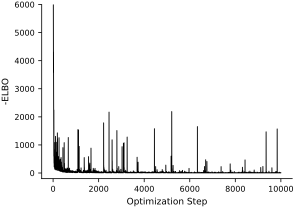

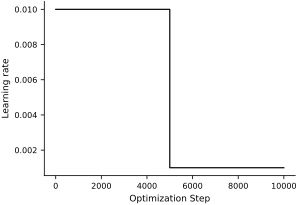

In [15]:
# Plot the loss and learning rate        
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(history['steps'], history['losses'], color=BOOK_GRAYS['black'], linewidth=0.9)
ax.set_ylim(-200, 6000)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('-ELBO')
finalize_axes(keep_box=False)
plt.show()

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.step(history['steps'], history['learning_rates'], where='post', color=BOOK_GRAYS['black'], linewidth=1.2)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Learning rate')
finalize_axes(keep_box=False)
plt.show();

### Evaluation

After training, we want to examine how well our amortized inference network performs the inference on a few target systems with known ground truth for the joint configurations.

In [16]:
def draw_isolines(samples, filter_width):
    """
    Draw probability density isolines for end-effector positions.
    
    Args:
        samples: Joint configuration samples
        filter_width: Gaussian filter width for smoothing
    """
    if not filter_width > 0:
        return

    # Forward kinematics
    result = forward_process(jnp.array(samples))
    y = np.array(result['D'])
    
    valid_mask = np.isfinite(y[:, 0]) & np.isfinite(y[:, 1])
    if not np.any(valid_mask):
        return

    # Define plotting range
    rangex = (-0.35, 2.25)
    rangey = (-2.0, 1.3)

    # Compute 2D histogram of end-effector positions
    hist, xbins, ybins = np.histogram2d(
        y[:, 0], y[:, 1], 
        bins=600, 
        range=[rangex, rangey], 
        density=True
    )

    # Smooth histogram with Gaussian filter
    hist = gaussian_filter(hist, filter_width)

    # Find threshold for 3% probability mass
    percentile = 0.03 * np.sum(hist)
    for q in np.logspace(-99, np.log10(np.max(hist)), 8000, endpoint=True):
        if np.sum(hist[hist < q]) > percentile: break
    else:
        q = 1.0

    # Create meshgrid for contour plot
    X, Y = np.meshgrid(
        0.5 * (xbins[:-1] + xbins[1:]),
        0.5 * (ybins[:-1] + ybins[1:])
    )

    # Draw contour line
    plt.contour(
        X, Y, hist.T, [q], linewidths=0.9, linestyles='--',
        zorder=3, colors=[BOOK_GRAYS['dark']]
    )


def plot_reconstructed(xi_samples, xi_data, y_data, lens, filter_width=4.0, arrows=False):
    """
    Plot reconstructed trajectories from AVI samples and ground truth.
    
    Args:
        xi_samples: Posterior samples from AVI
        xi_data: Ground truth joint configuration
        y_data: Observed end-effector position
        lens: Link lengths
        filter_width: Gaussian filter width for isolines
        arrows: Whether to show arrows (unused, kept for compatibility)
    """
    fig = plt.figure(figsize=FIGURE_SIZES["half_tall"])
    axarr = fig.add_subplot(1, 1, 1)
    
    lens = np.array(lens)
    xi = np.array(xi_samples)
    y_target = y_data[0]
    
    # Forward kinematics for AVI samples
    result = forward_process(jnp.array(xi))
    xi0 = np.array(result['A'])
    xi1 = np.array(result['B'])
    xi2 = np.array(result['C'])
    xi3 = np.array(result['D'])

    # Draw reference lines
    plt.axvline(x=0, ls=':', linewidth=0.75, color=BOOK_GRAYS['medium'])
    if not arrows:
        # Draw crosshair at target position
        l_cross = 0.6
        plt.plot(
            [y_target[0] - l_cross, y_target[0] + l_cross], 
            [y_target[1], y_target[1]], 
            ls=':', linewidth=0.75, color=BOOK_GRAYS['medium'], alpha=0.7, zorder=-1
        )
        plt.plot(
            [y_target[0], y_target[0]], 
            [y_target[1] - l_cross, y_target[1] + l_cross], 
            ls=':', linewidth=0.75, color=BOOK_GRAYS['medium'], alpha=0.7, zorder=-1
        )
    
    # Plot AVI sample trajectories (many transparent links)
    opts_avi = {
        'alpha': 0.035, 'scale': 1, 'angles': 'xy', 'scale_units': 'xy',
        'headlength': 0, 'headaxislength': 0, 'linewidth': 1.0, 'rasterized': True
    }
    avi_legend_line = Line2D([0], [0], color=BOOK_GRAYS['light'], linewidth=1.8, label='AVI samples')
    plt.quiver(xi0[:, 0], xi0[:, 1], (xi1 - xi0)[:, 0], (xi1 - xi0)[:, 1], 
               color=BOOK_GRAYS['light'], **opts_avi)
    plt.quiver(xi1[:, 0], xi1[:, 1], (xi2 - xi1)[:, 0], (xi2 - xi1)[:, 1], 
               color=BOOK_GRAYS['light'], **opts_avi)
    plt.quiver(xi2[:, 0], xi2[:, 1], (xi3 - xi2)[:, 0], (xi3 - xi2)[:, 1], 
               color=BOOK_GRAYS['light'], **opts_avi)
    
    # Plot ground truth trajectory
    result_sample = forward_process(jnp.array(xi_data))
    A = np.array(result_sample['A'])
    B = np.array(result_sample['B'])
    C = np.array(result_sample['C'])
    D = np.array(result_sample['D'])
    
    # Draw ground truth links
    gt_line = plt.plot(
        [A[0, 0], B[0, 0], C[0, 0]],
        [A[0, 1], B[0, 1], C[0, 1]],
        '-', linewidth=1.5, color=BOOK_GRAYS['black'], marker='o',
        markerfacecolor='white', markeredgecolor=BOOK_GRAYS['black'],
        markersize=3.5, zorder=4, label='Ground truth'
    )[0]
    
    # Draw final link as arrow
    plt.arrow(
        C[0, 0], C[0, 1],
        D[0, 0] - C[0, 0], D[0, 1] - C[0, 1],
        linewidth=1, head_width=0.05, head_length=0.04, overhang=0.1,
        length_includes_head=True, color=BOOK_GRAYS['black'], zorder=4
    )
    
    # Mark base joints
    plt.scatter(
        [A[0, 0]], [A[0, 1]],
        s=100, marker='s', linewidth=1,
        facecolors='white', edgecolors=BOOK_GRAYS['black'], zorder=3
    )
    plt.scatter(
        [A[0, 0], B[0, 0], C[0, 0]],
        [A[0, 1], B[0, 1], C[0, 1]],
        s=10, marker='o', linewidth=1,
        facecolors='white', edgecolors=BOOK_GRAYS['black'], zorder=5
    )

    # Draw probability density isolines
    draw_isolines(xi, filter_width)
    
    plt.xlabel('')
    plt.ylabel('')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(handles=[avi_legend_line, gt_line], loc='best')
    finalize_axes(keep_box=True)
    plt.show()

In [17]:
def pair_plot(prior_samples, avi_samples, xi_data):
    """
    Create pair plot comparing prior and AVI posterior distributions.
    
    Args:
        prior_samples: Array of shape (xi_dim, n_samples) - each row is a dimension
        avi_samples: Array of shape (xi_dim, n_samples) - each row is a dimension
        xi_data: Array of shape (1, xi_dim) - ground truth values
    """
    # Filter out NaN and inf values
    prior_samples = np.where(np.isfinite(prior_samples), prior_samples, np.nan)
    avi_samples = np.where(np.isfinite(avi_samples), avi_samples, np.nan)
    
    xi_dim = prior_samples.shape[0]
    column_labels = [r'$\xi_{%.0f}$' % (i + 1) for i in range(xi_dim)]
    fig, axes = plt.subplots(
        xi_dim, xi_dim, 
        figsize=FIGURE_SIZES["full_tall"], 
        sharex="col", 
        constrained_layout=True
    )
    
    # Fill each subplot
    for i in range(xi_dim):
        for k in range(xi_dim):
            # lower-triangle
            if i > k:
                axes[i, k].scatter(
                    prior_samples[k], prior_samples[i], 
                    s=7, marker='o', facecolors='none',
                    edgecolors=BOOK_GRAYS['medium'], linewidths=0.4,
                    alpha=0.45, label='Prior', rasterized=True
                )
                axes[i, k].scatter(
                    avi_samples[k], avi_samples[i], 
                    s=7, marker='x', color=BOOK_GRAYS['dark'],
                    linewidths=0.45, alpha=0.45, label='AVI', rasterized=True
                )
                axes[i, k].set_xlabel(None)
                axes[i, k].set_ylabel(None)

            # main diagonal
            if i == k:
                # Plot prior KDE
                if len(prior_samples[k]) > 1:
                    kde_prior = gaussian_kde(prior_samples[k])
                    x_prior = np.linspace(
                        prior_samples[k].min(), 
                        prior_samples[k].max(), 
                        200
                    )
                    axes[i, k].plot(
                        x_prior, kde_prior(x_prior), 
                        label='Prior', color=BOOK_GRAYS['medium'], linestyle='--'
                    )
                
                # Plot AVI KDE
                if len(avi_samples[k]) > 1:
                    kde_avi = gaussian_kde(avi_samples[k])
                    x_avi = np.linspace(
                        avi_samples[k].min(), 
                        avi_samples[k].max(), 
                        200
                    )
                    axes[i, k].plot(
                        x_avi, kde_avi(x_avi), 
                        label='AVI', color=BOOK_GRAYS['black'], linestyle='-'
                    )
                
                # Ground truth
                axes[i, k].axvline(
                    x=xi_data[0][k], color=BOOK_GRAYS['black'],
                    ls=':', linewidth=1.3, label='Ground truth'
                )
                axes[i, k].set_ylim(bottom=0)
                axes[i, k].set_xlabel(None)
                axes[i, k].set_ylabel(None)

            # upper triangle
            if i < k:
                axes[i, k].remove()
                     
    for i, col in enumerate(column_labels):
        axes[i, 0].set_ylabel(col)
        axes[-1, i].set_xlabel(col)
    legend_handles = [
        Line2D([0], [0], color=BOOK_GRAYS['medium'], linestyle='--',
               marker='o', markerfacecolor='white', label='Prior'),
        Line2D([0], [0], color=BOOK_GRAYS['black'], linestyle='-',
               marker='x', label='AVI'),
        Line2D([0], [0], color=BOOK_GRAYS['black'], linestyle=':',
               label='Ground truth'),
    ]
    fig.legend(
        handles=legend_handles, loc='upper center', ncol=3,
        bbox_to_anchor=(0.5, 1.02), frameon=False,
        handlelength=2.2, columnspacing=1.0
    )
    finalize_axes(keep_box=False)
    plt.show()

Let's take a look at the AVI posterior distribution and reconstructed configuration for 5 different cases. Note that once the AVI is trained, the inference step runs on-the-fly.

------------------------------------------------------------
Groundtruth for Case 1:
 xi_data=[-0.31714088  0.06949134 -0.19751059  0.15957566],
 y_data=[ 1.9888455  -0.31583783]
Estimated mean:
[ 0.00943142 -0.17897418  0.01897797  0.00393981]
Estimated covariance matrix:
[[ 0.00081105 -0.0014369   0.00146741 -0.00013176]
 [-0.0014369   0.01359194 -0.01765165  0.00079339]
 [ 0.00146741 -0.01765165  0.03655675 -0.02093762]
 [-0.00013176  0.00079339 -0.02093762  0.02985677]]


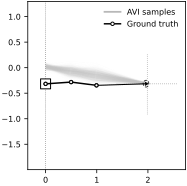

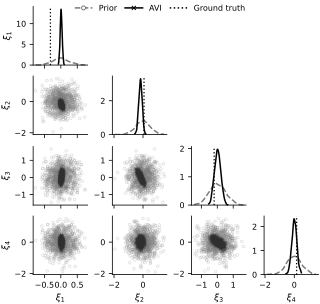

------------------------------------------------------------
Groundtruth for Case 2:
 xi_data=[ 0.28787988 -0.2765343   0.01023765  0.16922261],
 y_data=[ 1.9452722  -0.07970177]
Estimated mean:
[ 0.2710352  -0.18156719 -0.01947331  0.02582826]
Estimated covariance matrix:
[[ 0.00091945 -0.00019593  0.00262981 -0.00443653]
 [-0.00019593  0.01170094 -0.0144376  -0.00147291]
 [ 0.00262981 -0.0144376   0.03813522 -0.03063638]
 [-0.00443653 -0.00147291 -0.03063638  0.05282469]]


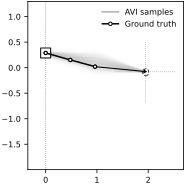

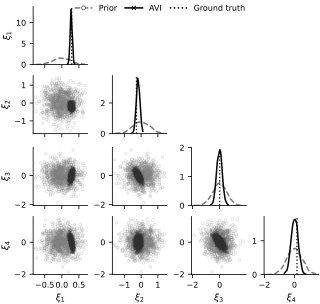

------------------------------------------------------------
Groundtruth for Case 3:
 xi_data=[-0.07957558  0.13758607  0.7067975  -0.12045325],
 y_data=[1.5913992 1.0126145]
Estimated mean:
[-0.17533267  0.56461465  0.10382407 -0.00205089]
Estimated covariance matrix:
[[ 4.5324501e-04 -1.4604935e-03  1.7383193e-03 -6.1282139e-05]
 [-1.4604935e-03  1.4104520e-02 -1.7339895e-02 -7.6780154e-04]
 [ 1.7383193e-03 -1.7339895e-02  3.3086482e-02 -1.6549308e-02]
 [-6.1282139e-05 -7.6780154e-04 -1.6549308e-02  2.6323372e-02]]


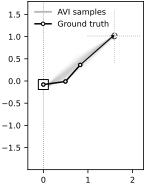

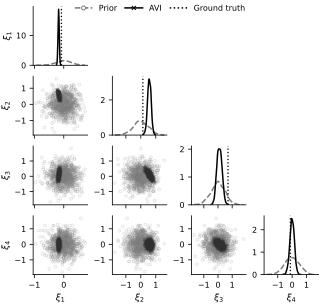

------------------------------------------------------------
Groundtruth for Case 4:
 xi_data=[-0.03204953 -0.75268656 -0.30555534 -0.3003993 ],
 y_data=[ 0.8258672 -1.7728025]
Estimated mean:
[ 2.4404883e-02 -9.5716357e-01 -2.3901221e-01  2.9613636e-04]
Estimated covariance matrix:
[[ 0.00029874 -0.00137885  0.00144549  0.00042993]
 [-0.00137885  0.01493861 -0.01644706 -0.00434939]
 [ 0.00144549 -0.01644706  0.02926843 -0.01195675]
 [ 0.00042993 -0.00434939 -0.01195675  0.02647991]]


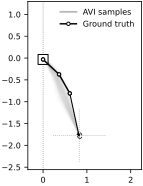

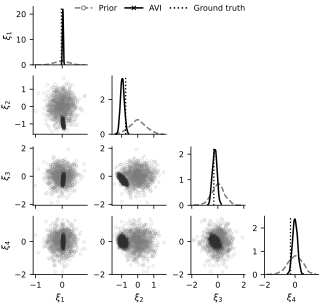

In [18]:
# Evaluation: Test trained model on multiple cases
n_samples = 1000  # Number of posterior samples to draw
postprocess_key = jr.PRNGKey(3)

for j in range(4):
    # Generate test case
    postprocess_key, data_key = jr.split(postprocess_key)
    xi_data, y_data = model.observed_data(data_key, n=1)
    
    # Infer posterior parameters from observation
    # From AVI trained inference function
    mean = model.mu(y_data[0, :])
    L_diag = model.L_diag(y_data[0, :])
    L_offdiag = model.L_offdiag(y_data[0, :])
    L = unpack_cholesky(L_diag, L_offdiag, model.xi_dim)

    # Convert to numpy for printing
    xi_data_np = np.array(xi_data[0])
    y_data_np = np.array(y_data[0])

    print('-' * 60)
    print(f"Groundtruth for Case {j+1}:\n xi_data={xi_data_np},\n y_data={y_data_np}")
    mean_np = np.array(mean)
    cov_np = np.array(L @ L.T)
    print('Estimated mean:\n' + str(mean_np))
    print('Estimated covariance matrix:\n' + str(cov_np))
    
    # Sample from AVI posterior
    postprocess_key, sample_key = jr.split(postprocess_key)
    zs = jr.normal(sample_key, (n_samples, model.xi_dim))
    xi_samples_AVI = mean[None, :] + zs @ L.T
    xi_samples_AVI_np = np.array(xi_samples_AVI)

    # Visualize reconstructed trajectories
    plot_reconstructed(xi_samples_AVI, xi_data_np[None, :], y_data_np[None, :], lens)

    # Sample from prior
    postprocess_key, prior_key = jr.split(postprocess_key)
    prior_loc = jnp.array(model.prior_xi_dist['loc'])[:model.xi_dim]
    prior_scale = jnp.array(model.prior_xi_dist['scale'])[:model.xi_dim]
    Prior_data = prior_loc[None, :] + prior_scale[None, :] * jr.normal(
        prior_key, (n_samples, model.xi_dim)
    )
    Prior_data_np = np.array(Prior_data).T
    AVI_data_np = xi_samples_AVI_np.T
    
    # Plot pair
    pair_plot(Prior_data_np, AVI_data_np, xi_data_np[None, :])

The trained AVI approximation works well for some configurations, but for others it does not cover the true trajectory. The inverse kinematics problem is non-identifiable because different joint configurations can produce the same end-effector position, while reverse-KL variational inference tends to concentrate on one mode and can underestimate posterior uncertainty. The discrepancy may therefore reflect an approximation gap, because the Gaussian guide family is too restrictive, or an amortization gap, because the inference network does not return the best Gaussian for a given observation. As an exercise, increase the network depth or width and compare the result with separately optimized variational inference in the same Gaussian family; this separates network expressiveness from guide-family limitations.